In [1]:
from collections import defaultdict

import nibabel

from mri_loader import Subject, MRI
from nilearn.glm.first_level import FirstLevelModel

import pandas as pd
import numpy as np

from stats import *




In [2]:
# for meet: maybe event time != process time

subject_ids = set(range(1, 34))
# subject_ids -= {1, 3, 13, 22, 32, 33}  # fucked data

subject_ids -= set(range(27, 34))  # exclude SCZ

# subject_ids = list(subject_ids)

# subject_ids = [13]

run_ids = list(range(1,5))
# run_ids = [1]

print(subject_ids, run_ids)

{1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26} [1, 2, 3, 4]


In [3]:

exclude_inflexion = set()


for subject in subject_ids:
    try:
        dataset = Subject(subject, run_ids)

        low_inflexion, high_inflexion = dataset.compute_inflexions()

        if low_inflexion < 0.1 or high_inflexion > 0.9 or high_inflexion < 0.5 or low_inflexion > 0.5:
            exclude_inflexion.add(subject)
    except:
        exclude_inflexion.add(subject)
        continue



D:\github\scz_familiarity_fMRI_ML\stats.py:27: RuntimeWarning: overflow encountered in exp
  y = L / (1 + np.exp(-k*(x-x0))) + b
D:\github\scz_familiarity_fMRI_ML\stats.py:27: RuntimeWarning: overflow encountered in exp
  y = L / (1 + np.exp(-k*(x-x0))) + b
D:\github\scz_familiarity_fMRI_ML\stats.py:27: RuntimeWarning: overflow encountered in exp
  y = L / (1 + np.exp(-k*(x-x0))) + b
D:\github\scz_familiarity_fMRI_ML\stats.py:27: RuntimeWarning: overflow encountered in exp
  y = L / (1 + np.exp(-k*(x-x0))) + b
D:\github\scz_familiarity_fMRI_ML\stats.py:27: RuntimeWarning: overflow encountered in exp
  y = L / (1 + np.exp(-k*(x-x0))) + b
D:\github\scz_familiarity_fMRI_ML\stats.py:27: RuntimeWarning: overflow encountered in exp
  y = L / (1 + np.exp(-k*(x-x0))) + b
D:\github\scz_familiarity_fMRI_ML\stats.py:27: RuntimeWarning: overflow encountered in exp
  y = L / (1 + np.exp(-k*(x-x0))) + b
D:\github\scz_familiarity_fMRI_ML\stats.py:27: RuntimeWarning: overflow encountered in exp
  y = 

In [4]:
exclude_inflexion

{8, 9, 10, 12, 20, 23, 24, 25}

In [5]:
Subject(list(subject_ids)[0], run_ids).sample_mask

array([  0,   5,   6,   7,   8,   9,  10,  11,  12,  13,  14,  15,  16,
        17,  18,  19,  20,  21,  22,  23,  24,  25,  26,  27,  28,  29,
        30,  31,  32,  33,  34,  35,  36,  37,  38,  39,  40,  41,  42,
        43,  44,  45,  46,  47,  48,  49,  50,  51,  52,  53,  54,  55,
        56,  57,  58,  59,  60,  61,  62,  63,  64,  65,  66,  67,  68,
        69,  70,  71,  72,  73,  74,  75,  76,  77,  78,  79,  80,  81,
        82,  83,  84,  85,  86,  87,  88,  89,  90,  91,  92,  93,  94,
        95,  96,  97,  98,  99, 100, 101, 102, 103, 104, 105, 106, 107,
       108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120,
       121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133,
       134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146,
       147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 158, 159, 160,
       161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173,
       174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 18

In [9]:
labels_col, morph_resp = "morph level", True
# labels_col, morph_resp = "response", False



In [10]:
subject_ids -= exclude_inflexion

subject_ids

{1, 2, 3, 4, 5, 6, 7, 11, 13, 14, 15, 16, 17, 18, 19, 21, 22, 26}

In [11]:
#subject_ids = set(range(27, 34))  # override, run on SCZ

In [12]:
len(subject_ids)

18

In [13]:

global_z_map = {}

contrast_list = [{"+": ["high"], "-": ["low"]},  # high > low
                 {"+": ["undecided"], "-": ["high", "low"]},]  # undecided > high + low

scale = [["25", "35"], ["35", "45"], ["45", "55"], ["55", "65"], ["65", "75"], ["75", "85"], ["85", "95"]]
to_subtract = {"-": ["5", "15"]}

contrast_list += [{"+": ["55", "65", "75", "85", "95"], "-": ["15", "25", "35", "45"]}]


for values in scale:
    contrast_list.append({
        "+": values,
        **to_subtract
    })

if labels_col == "response":
    contrast_list = [{"+": ["1"], "-": ["0"]}]  # override
else:
    contrast_list += [{"+": ["button"], "-": ["unpressed"]}]

for classes in contrast_list:
    name = contrast_name(classes)
    global_z_map[name] = []

global_z_map

{'high > low': [],
 'undecided > high + low': [],
 '55 + 65 + 75 + 85 + 95 > 15 + 25 + 35 + 45': [],
 '25 + 35 > 5 + 15': [],
 '35 + 45 > 5 + 15': [],
 '45 + 55 > 5 + 15': [],
 '55 + 65 > 5 + 15': [],
 '65 + 75 > 5 + 15': [],
 '75 + 85 > 5 + 15': [],
 '85 + 95 > 5 + 15': [],
 'button > unpressed': []}

In [15]:

skipped = []

for subject in subject_ids:

    try:
        dataset = Subject(subject, run_ids, confound_mode="full", volumes_offset=0)
        dataset.load()

        images, times, labels = dataset.get_data(labels_col=labels_col, morph_response=morph_resp)
        durations = dataset.get_durations()
        low_inflexion, high_inflexion = dataset.compute_inflexions()

        sample_mask = dataset.sample_mask
    except Exception as e:
        print("Skipping subject ", subject)
        print(e)
        skipped.append(subject)
        continue

    print(f"{subject=} {low_inflexion=}, {high_inflexion=}")

    labels_class = set(labels)

    events = pd.DataFrame(
        {'onset': times,
         'trial_type': labels,
         'duration': durations}
    )

    repetition_time = dataset.repetition_time
    fmri_glm = FirstLevelModel(t_r=repetition_time,
              drift_model='polynomial',
              drift_order=3,
              hrf_model='spm',
              mask_img=dataset.brain_mask,
              smoothing_fwhm=4,
              n_jobs=-1)

    fmri_glm = fmri_glm.fit(images, events, sample_masks=sample_mask)
    # fmri_glm = fmri_glm.fit(images, events)

    design_matrix = fmri_glm.design_matrices_[0]

    contrast_matrix = np.eye(design_matrix.shape[1])
    contrasts = {
        str(column): contrast_matrix[i]
        for i, column in enumerate(design_matrix.columns)
    }

    if labels_col == "morph level":
        parse_contrast(contrasts, low_inflexion, high_inflexion)

    for contrast in contrast_list:

        glm_contrast_vector  = sum(contrasts[column] for column in contrast["+"])
        if '-' in contrast:
            glm_contrast_vector -= sum(contrasts[column] for column in contrast["-"])

        z_score = fmri_glm.compute_contrast(glm_contrast_vector, output_type="z_score")
        name = contrast_name(contrast)

        global_z_map[name].append(z_score)




D:\github\scz_familiarity_fMRI_ML\stats.py:27: RuntimeWarning: overflow encountered in exp
  y = L / (1 + np.exp(-k*(x-x0))) + b


subject=1 low_inflexion=np.float64(0.2806306306306306), high_inflexion=np.float64(0.7391891891891892)
subject=2 low_inflexion=np.float64(0.2698198198198198), high_inflexion=np.float64(0.613063063063063)


D:\github\scz_familiarity_fMRI_ML\stats.py:27: RuntimeWarning: overflow encountered in exp
  y = L / (1 + np.exp(-k*(x-x0))) + b


subject=3 low_inflexion=np.float64(0.19684684684684683), high_inflexion=np.float64(0.7022522522522522)


D:\github\scz_familiarity_fMRI_ML\stats.py:27: RuntimeWarning: overflow encountered in exp
  y = L / (1 + np.exp(-k*(x-x0))) + b


...

subject=19 low_inflexion=np.float64(0.24189189189189186), high_inflexion=np.float64(0.7202702702702702)


D:\github\scz_familiarity_fMRI_ML\stats.py:27: RuntimeWarning: overflow encountered in exp
  y = L / (1 + np.exp(-k*(x-x0))) + b


subject=21 low_inflexion=np.float64(0.11486486486486486), high_inflexion=np.float64(0.7328828828828828)
Skipping subject  22
Compressed file ended before the end-of-stream marker was reached


D:\github\scz_familiarity_fMRI_ML\stats.py:27: RuntimeWarning: overflow encountered in exp
  y = L / (1 + np.exp(-k*(x-x0))) + b


subject=26 low_inflexion=np.float64(0.140990990990991), high_inflexion=np.float64(0.6986486486486486)


In [16]:
from nilearn.reporting import get_clusters_table
from nilearn.glm import threshold_stats_img
from nilearn.plotting import plot_stat_map
from brain_map import find_region_names

from nilearn import datasets

import matplotlib.pyplot as plt


In [17]:
z_map_subjects = set(subject_ids)
z_map_subjects -= set(skipped)

plt.style.use('dark_background')

if False:  # avoid plot each time

    for contrast_name, images in global_z_map.items():
        for z_score, subject in zip(images, z_map_subjects):

            clean_z, threshold = threshold_stats_img(z_score, alpha=0.001, height_control="bonferroni", cluster_threshold=5)
            cut_coords_list = [
                (0, 0, 0),
                (10, -20, 30),
                (-15, 10, 45),
            ]

            n_coords = len(cut_coords_list)

            fig, axes = plt.subplots(
                n_coords, 1,
                figsize=(15, 4 * n_coords)
            )

            fig.suptitle(contrast_name, fontweight="bold")

            bg_run = MRI(subject, 1)

            for ax, coords in zip(axes, cut_coords_list):
                plot_stat_map(
                    clean_z,
                    display_mode='ortho',
                    cut_coords=coords,
                    axes=ax,
                    bg_img=bg_run.background,
                    title=f"Ortho @ {coords}",
                    colorbar=True
                )

            plt.tight_layout()
            fname = contrast_name.replace(' ', '_').replace('>', 'over')
            plt.savefig(f"graphs/contrasts/sub-{subject}-contrast-{fname}.png")

In [18]:
from lib.mni_to_atlas import AtlasBrowser
import numpy as np

atlas = AtlasBrowser("AAL3")



In [24]:
mni_regions = {}

for co_name, images in global_z_map.items():
    mni_regions[co_name] = []

    for z_score in images:

        clean, threshold = threshold_stats_img(z_score, alpha=0.001, height_control="fpr", cluster_threshold=5)
#        clean, threshold = threshold_stats_img(z_score, alpha=0.05, height_control="bonferroni", cluster_threshold=5)
        table = get_clusters_table(clean, stat_threshold=threshold, cluster_threshold=5)

        pos = [np.array([x,y,z]) for (x,y,z) in zip(table['X'], table['Z'], table['Y'])]
        with pd.option_context('display.max_rows', None, 'display.max_columns', None):  # more options can be specified also
            print(co_name)
            print(table)

        for p in pos:
            try:
                projected_coords = atlas.project_to_nearest(p)
                projected_regions = atlas.find_regions(projected_coords)

                mni_regions[co_name].append(*projected_regions)
            except Exception as e:
                print(e)


high > low
   Cluster ID     X     Y          Z  Peak Stat Cluster Size (mm3)
0           1 -21.5 -27.5 -17.300002   5.877678                550
1           2  32.5 -51.5 -24.500001   5.443941                194
2           3 -27.5   8.5  72.699996   5.187985                259
3           4  -9.5 -57.5  40.299997   5.102108                161
4           5 -21.5  50.5  43.899997   5.003674                194
5           6 -15.5  35.5  40.299997   4.867288                226
6           7 -39.5  11.5  11.499998   4.864696                194
7           8  26.5 -15.5  40.299997   4.853244                194
8           9   2.5  53.5 -13.700002   4.714572               1004
9          9a  -6.5  59.5  -6.500002   4.656602                   
10         9b   2.5  62.5 -13.700002   4.076706                   
11         10   2.5 -30.5  -6.500002   4.700474                194
12         11 -60.5  -9.5  43.899997   4.672821                161
13         12  -9.5  59.5  40.299997   4.657025    

C:\Users\ducat\AppData\Local\Temp\ipykernel_3680\2597154520.py:8: UserWarning: The given float value must not exceed 2.9117278820264243. But, you have given threshold=3.2905267314918945.
  clean, threshold = threshold_stats_img(z_score, alpha=0.001, height_control="fpr", cluster_threshold=5)
C:\Users\ducat\AppData\Local\Temp\ipykernel_3680\2597154520.py:10: UserWarning: The given float value must not exceed 0.0. But, you have given threshold=3.2905267314918945.
  table = get_clusters_table(clean, stat_threshold=threshold, cluster_threshold=5)
C:\Users\ducat\AppData\Local\Temp\ipykernel_3680\2597154520.py:10: UserWarning: No clusters found with stat higher than 3.2905267314918945
  table = get_clusters_table(clean, stat_threshold=threshold, cluster_threshold=5)


high > low
Empty DataFrame
Columns: [Cluster ID, X, Y, Z, Peak Stat, Cluster Size (mm3)]
Index: []
high > low
   Cluster ID     X     Y          Z  Peak Stat Cluster Size (mm3)
0           1   5.5 -69.5  51.099997   7.593169              10562
1          1a  -9.5 -36.5  40.299997   6.371052                   
2          1b  -6.5 -51.5  47.499997   5.931007                   
3          1c  -9.5 -72.5  54.699996   5.846519                   
4           2 -51.5  32.5  25.899997   7.131686               3628
5          2a -39.5  44.5  15.099998   6.265477                   
6          2b -48.5  35.5  36.699997   5.577615                   
7          2c -39.5  41.5  36.699997   4.866564                   
8           3  44.5 -75.5  25.899997   6.518234               1684
9          3a  38.5 -81.5  36.699997   5.494119                   
10         3b  41.5 -84.5  25.899997   5.020548                   
11          4 -21.5   5.5  61.899996   6.506659               2624
12         4a -15.5

C:\Users\ducat\AppData\Local\Temp\ipykernel_3680\2597154520.py:10: UserWarning: The given float value must not exceed 0.0. But, you have given threshold=3.2905267314918945.
  table = get_clusters_table(clean, stat_threshold=threshold, cluster_threshold=5)
C:\Users\ducat\AppData\Local\Temp\ipykernel_3680\2597154520.py:10: UserWarning: No clusters found with stat higher than 3.2905267314918945
  table = get_clusters_table(clean, stat_threshold=threshold, cluster_threshold=5)


high > low
Empty DataFrame
Columns: [Cluster ID, X, Y, Z, Peak Stat, Cluster Size (mm3)]
Index: []
high > low
   Cluster ID     X      Y          Z  Peak Stat Cluster Size (mm3)
0           1 -21.5    5.5 -20.900002   6.556674                421
1           2  17.5  -96.5 -20.900002   6.203918                323
2           3  38.5  -48.5 -31.700001   5.838647                485
3           4  -3.5  -87.5 -46.100001   5.788221                356
4           5  59.5  -54.5 -17.300002   5.579142                291
5           6  17.5    8.5 -20.900002   5.428896                583
6           7  -6.5  -27.5 -49.700001   5.391445                647
7          7a   5.5  -21.5 -46.100001   4.681345                   
8           8  -0.5  -93.5 -17.300002   5.323595                323
9           9   8.5    2.5  22.299997   5.312729                550
10         10  20.5    8.5  72.699996   5.295052                745
11        10a  26.5   -0.5  72.699996   4.609238                   
12    

...

85 + 95 > 5 + 15
Empty DataFrame
Columns: [Cluster ID, X, Y, Z, Peak Stat, Cluster Size (mm3)]
Index: []
85 + 95 > 5 + 15
   Cluster ID     X     Y          Z  Peak Stat Cluster Size (mm3)
0           1   5.5 -69.5  51.099997   6.342991               3887
1          1a  -9.5 -72.5  43.899997   5.116042                   
2          1b  -6.5 -63.5  61.899996   4.584863                   
3          1c  14.5 -75.5  51.099997   4.573488                   
4           2 -39.5  11.5   7.899998   6.141958                485
5           3  -6.5 -51.5  47.499997   5.672813               2170
6          3a  -6.5 -39.5  47.499997   4.885982                   
7          3b  -0.5 -45.5  58.299996   4.453039                   
8           4 -21.5   5.5  54.699996   5.658317                583
9           5   5.5 -33.5  40.299997   5.453459                680
10         5a   5.5 -39.5  33.099997   4.121890                   
11         5b   5.5 -36.5  47.499997   3.891459                   
12     

C:\Users\ducat\AppData\Local\Temp\ipykernel_3680\2597154520.py:10: UserWarning: The given float value must not exceed 0.0. But, you have given threshold=3.2905267314918945.
  table = get_clusters_table(clean, stat_threshold=threshold, cluster_threshold=5)
C:\Users\ducat\AppData\Local\Temp\ipykernel_3680\2597154520.py:10: UserWarning: No clusters found with stat higher than 3.2905267314918945
  table = get_clusters_table(clean, stat_threshold=threshold, cluster_threshold=5)


85 + 95 > 5 + 15
Empty DataFrame
Columns: [Cluster ID, X, Y, Z, Peak Stat, Cluster Size (mm3)]
Index: []
85 + 95 > 5 + 15
   Cluster ID     X      Y          Z  Peak Stat Cluster Size (mm3)
0           1 -21.5    5.5 -20.900002   6.558828                421
1           2  17.5  -96.5 -20.900002   6.255063                388
2           3  38.5  -48.5 -31.700001   5.862369                485
3           4  -3.5  -87.5 -46.100001   5.808410                388
4           5  59.5  -54.5 -17.300002   5.620264                323
5           6  17.5    8.5 -20.900002   5.418240                583
6           7  -6.5  -27.5 -49.700001   5.401288                647
7          7a   5.5  -21.5 -46.100001   4.654896                   
8           8  -0.5  -93.5 -17.300002   5.319771                356
9           9  20.5    8.5  72.699996   5.306672                745
10         9a  26.5   -0.5  72.699996   4.623959                   
11         10   8.5    2.5  22.299997   5.304436              

C:\Users\ducat\AppData\Local\Temp\ipykernel_3680\2597154520.py:10: UserWarning: The given float value must not exceed 0.0. But, you have given threshold=3.2905267314918945.
  table = get_clusters_table(clean, stat_threshold=threshold, cluster_threshold=5)
C:\Users\ducat\AppData\Local\Temp\ipykernel_3680\2597154520.py:10: UserWarning: No clusters found with stat higher than 3.2905267314918945
  table = get_clusters_table(clean, stat_threshold=threshold, cluster_threshold=5)


button > unpressed
Empty DataFrame
Columns: [Cluster ID, X, Y, Z, Peak Stat, Cluster Size (mm3)]
Index: []
button > unpressed
    Cluster ID     X     Y          Z  Peak Stat Cluster Size (mm3)
0            1 -36.5 -21.5   4.299998   6.904005               1036
1           1a -39.5  -6.5   4.299998   5.921916                   
2            2 -66.5 -24.5  15.099998   6.873852               3790
3           2a -63.5 -42.5  25.899997   6.124494                   
4           2b -54.5 -33.5  33.099997   5.303214                   
5           2c -60.5 -24.5  40.299997   5.272392                   
6            3 -60.5  14.5  -2.900002   6.261756               3401
7           3a -45.5   5.5  -2.900002   6.238189                   
8           3b -57.5  -9.5  11.499998   6.174815                   
9           3c -57.5  -3.5   4.299998   6.000035                   
10           4 -24.5  71.5  -2.900002   6.144730                777
11          4a -33.5  68.5  -6.500002   5.567936          

In [25]:
mni_regions_concat = {}

for k, v in mni_regions.items():

    reg_list = np.array(v, dtype=object)

    mni_regions_concat[k] = reg_list

In [26]:
mni_df = pd.DataFrame(dict([(k, pd.Series(v)) for k, v in mni_regions_concat.items()]))


In [27]:
mni_summary = pd.DataFrame({
    col.replace(' ', ''): mni_df[col].value_counts()
    for col in mni_df.columns
})

mni_summary = mni_summary.fillna(0)

mni_summary

,high>low,undecided>high+low,55+65+75+85+95>15+25+35+45,25+35>5+15,35+45>5+15,45+55>5+15,55+65>5+15,65+75>5+15,75+85>5+15,85+95>5+15,button>unpressed
ACC_pre_L,1.0,2.0,3.0,1.0,5.0,1.0,6.0,2.0,3.0,4.0,1.0
ACC_pre_R,0.0,4.0,0.0,3.0,4.0,3.0,1.0,4.0,0.0,1.0,3.0
ACC_sub_L,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
ACC_sub_R,1.0,0.0,0.0,0.0,1.0,1.0,2.0,0.0,0.0,0.0,0.0
ACC_sup_L,1.0,5.0,2.0,1.0,2.0,3.0,5.0,5.0,1.0,0.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...
Vermis_3,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0
Vermis_4_5,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
Vermis_7,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
Vermis_8,0.0,2.0,0.0,0.0,2.0,1.0,1.0,0.0,1.0,0.0,1.0


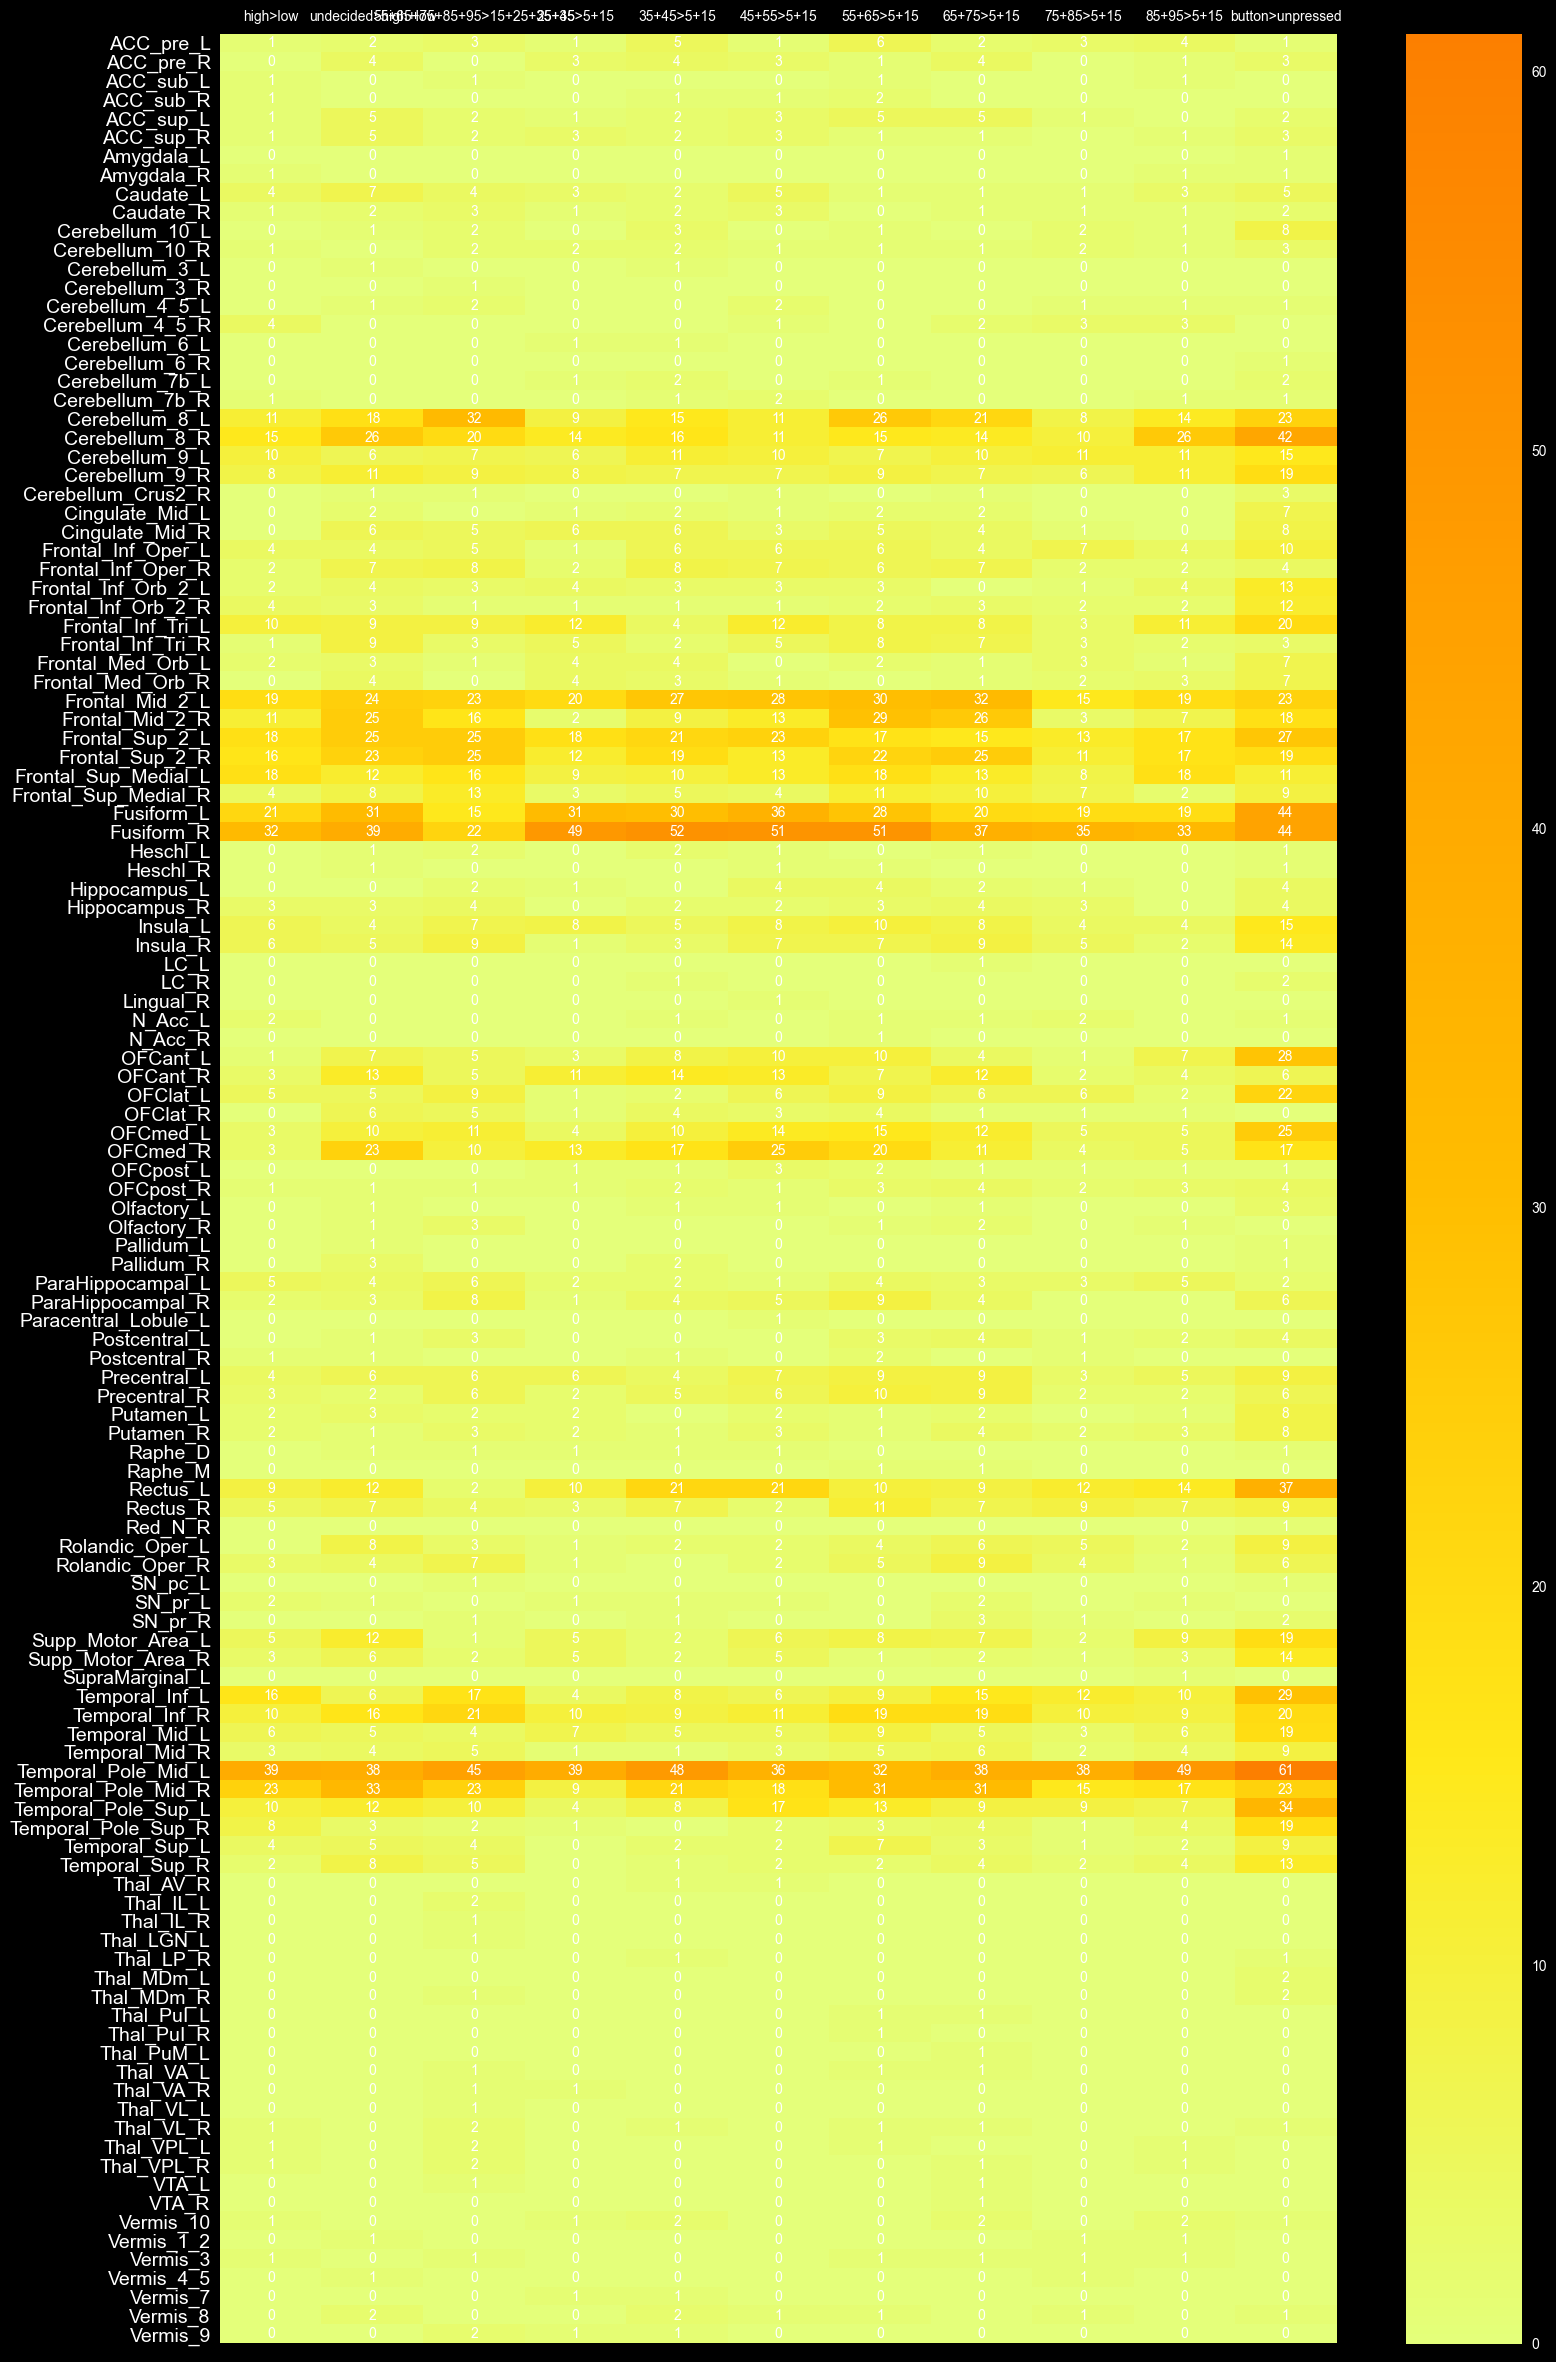

In [28]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(18, 30))
im = ax.imshow(mni_summary.values, cmap='Wistia', aspect='auto')

ax.set_xticks(range(len(mni_summary.columns)))
ax.set_yticks(range(len(mni_summary)))
ax.set_xticklabels(mni_summary.columns, fontsize=10)
ax.set_yticklabels(mni_summary.index, fontsize=14)

ax.xaxis.tick_top()

for i in range(len(mni_summary.index)):
    for j in range(len(mni_summary.columns)):
        ax.text(j, i, f'{mni_summary.values[i, j]:.0f}',
                ha='center', va='center', fontsize=10)

ax.grid(False)
ax.tick_params(which='both', length=0)

plt.colorbar(im)
plt.show()

In [ ]:
import nibabel

for contrast_name, images in global_z_map.items():

    for z_score, subject in zip(images, z_map_subjects):

        fname = contrast_name.replace(' ', '_').replace('>', 'over')

        if False:
            nibabel.save(z_score, f"contrasts/smoothed_3mm/sub-{subject}-{fname}.nii.gz")
